# 01 — Variant 1: U-Net + L1 baseline

Encoder-decoder with skip connections, pixel-wise L1 loss only,
no adversarial component. Reuses `Pix2PixTrainer` with `lambda_gan=0`.

In [2]:
import sys
sys.path.append("..")

import json
from pathlib import Path

import torch
from torch.utils.data import DataLoader

from src.data import AnimeColorizationDataset
from src.training import Pix2PixTrainer
from src.utils import seed_everything, plot_loss_curves, qualitative_grid, evaluate_model

seed_everything(42)

DATA_ROOT = Path("../data/anime_colorization")
CKPT_DIR = Path("../checkpoints/01_unet_l1")
FIG_DIR = Path("../results/figures")
TABLE_DIR = Path("../results/tables")

# Config
CONFIG = dict(
    image_size=256,
    batch_size=16,
    num_workers=8,
    epochs=50,
    lr=2e-4,
    lambda_l1=100.0,
    lambda_gan=0.0,       
    lambda_perceptual=0.0,
)

## Data

AnimeColorizationDatasets + paired DataLoaders for every split (train, val, test).

In [5]:
splits = {split: AnimeColorizationDataset(DATA_ROOT, split=split,
                                          image_size=CONFIG["image_size"])
          for split in ("train", "val", "test")}

train_loader = DataLoader(splits["train"], batch_size=CONFIG["batch_size"],
                          shuffle=True, num_workers=CONFIG["num_workers"],
                          pin_memory=True, drop_last=True, persistent_workers=True)
val_loader = DataLoader(splits["val"], batch_size=CONFIG["batch_size"],
                        shuffle=False, num_workers=CONFIG["num_workers"],
                        pin_memory=True, persistent_workers=True)
test_loader = DataLoader(splits["test"], batch_size=CONFIG["batch_size"],
                         shuffle=False, num_workers=CONFIG["num_workers"],
                         pin_memory=True, persistent_workers=True)

for split, ds in splits.items():
    print(f"{split:5s}: {len(ds):6d} images")

train:  14224 images
val  :   1772 images
test :   1773 images


## Training

`Pix2PixTrainer` with `lambda_gan=0`: only the U-Net generator is built, the loss is pure L1. Best checkpoint selected by `val_l1`. Resume by uncommenting `load_checkpoint`.

In [6]:
trainer = Pix2PixTrainer(
    train_loader=train_loader,
    val_loader=val_loader,
    checkpoint_dir=CKPT_DIR,
    lr=CONFIG["lr"],
    lambda_l1=CONFIG["lambda_l1"],
    lambda_gan=CONFIG["lambda_gan"],
    lambda_perceptual=CONFIG["lambda_perceptual"],
)

# To resume an interrupted run, uncomment:
# trainer.load_checkpoint("last.pt")

history = trainer.fit(CONFIG["epochs"])

epoch 1/50 [train]:   0%|          | 0/889 [00:00<?, ?it/s]

epoch 1/50 [val]:   0%|          | 0/111 [00:00<?, ?it/s]

epoch   1/50 | train_l1=0.1983 | train_g=19.8288 | val_l1=0.1638


epoch 2/50 [train]:   0%|          | 0/889 [00:00<?, ?it/s]

epoch 2/50 [val]:   0%|          | 0/111 [00:00<?, ?it/s]

...

epoch 49/50 [val]:   0%|          | 0/111 [00:00<?, ?it/s]

epoch  49/50 | train_l1=0.0663 | train_g=6.6276 | val_l1=0.1432


epoch 50/50 [train]:   0%|          | 0/889 [00:00<?, ?it/s]

epoch 50/50 [val]:   0%|          | 0/111 [00:00<?, ?it/s]

epoch  50/50 | train_l1=0.0658 | train_g=6.5832 | val_l1=0.1463


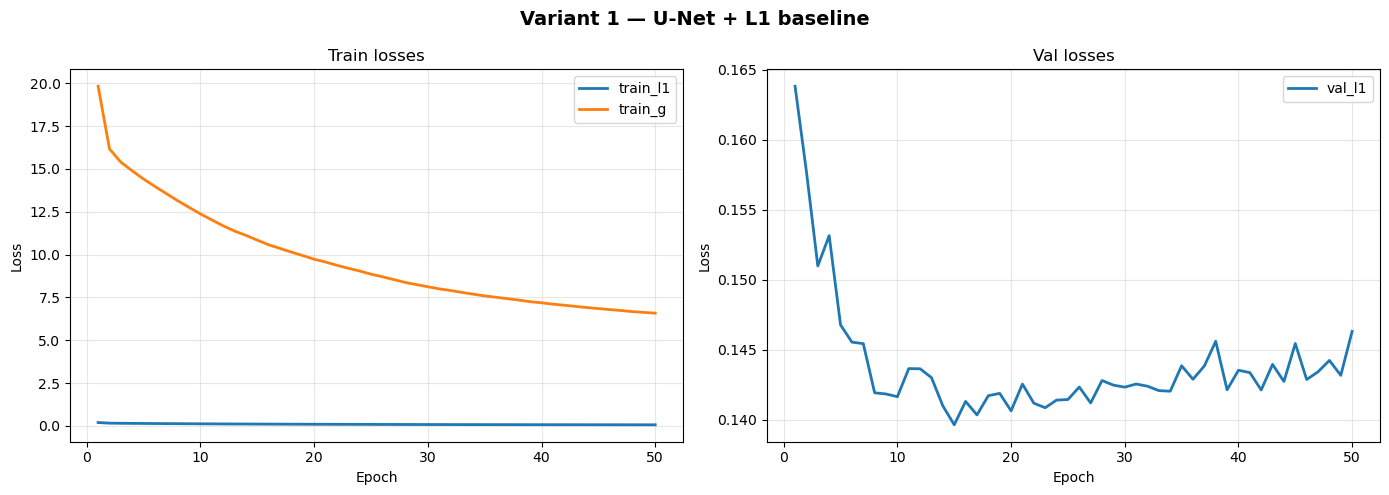

In [20]:
trainer.load_checkpoint("last.pt")
plot_loss_curves(trainer.history, title="Variant 1 — U-Net + L1 baseline",
                 save_path=FIG_DIR / "01_unet_l1_losses.png")

## Qualitative results

Best checkpoint (lowest `val_l1`), random test batch: sketch | prediction | ground truth. Expect plausible structure but desaturated, "averaged" colors — the known failure mode of pure L1.

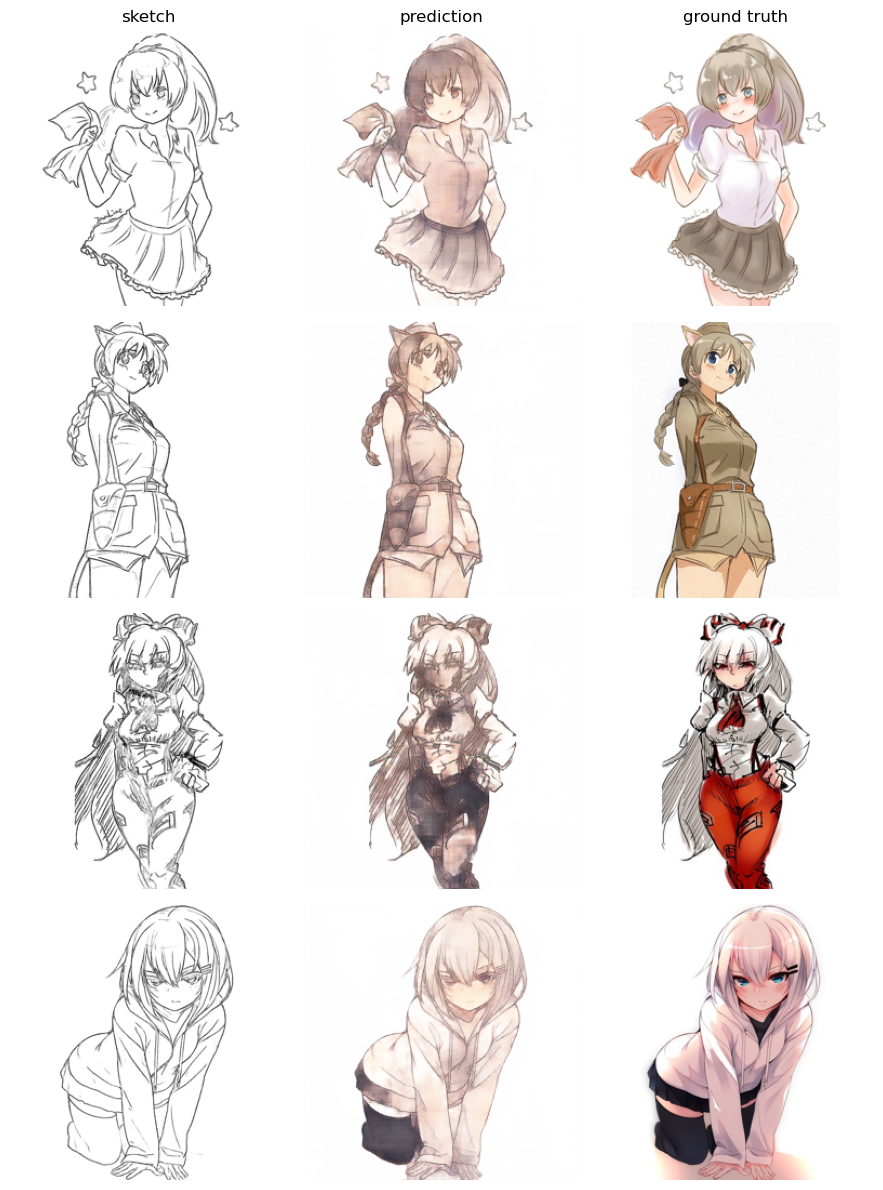

In [8]:
trainer.load_checkpoint("best.pt")

batch = next(iter(test_loader))
prediction = trainer.generate(batch["sketch"])
qualitative_grid(batch["sketch"], prediction, batch["color"], n_rows=4,
                 save_path=FIG_DIR / "01_unet_l1_grid.png")

## Quantitative evaluation (test set)

PSNR / SSIM / LPIPS / FID on the full test split, saved to `results/tables/01_unet_l1.json`.

In [9]:
metrics = evaluate_model(trainer.generator, test_loader,
                         fid_dir="../results/fid/01_unet_l1")
print(metrics)

TABLE_DIR.mkdir(parents=True, exist_ok=True)
with open(TABLE_DIR / "01_unet_l1.json", "w") as f:
    json.dump({"variant": "01_unet_l1", "config": CONFIG, "metrics": metrics}, f, indent=2)

/home/mmondo/miniconda3/envs/anime-colorization/lib/python3.10/site-packages/torchmetrics/functional/image/lpips.py:332: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.l

evaluate:   0%|          | 0/111 [00:00<?, ?it/s]

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /home/mmondo/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:03<00:00, 27.4MB/s]
100%|██████████| 36/36 [00:03<00:00,  9.67it/s]


{'psnr': 16.673927307128906, 'ssim': 0.8111435174942017, 'lpips': 0.19516418874263763, 'fid': np.float64(93.71012492821251)}
